# 03 — Modelling

**Input:** `data/cs_features.parquet`  
**Output:** `models/lr_final.pkl`, `models/scaler.pkl`, `models/xgb_final.json`

---

In [8]:
import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
%matplotlib inline

os.makedirs('models',  exist_ok=True)
os.makedirs('reports', exist_ok=True)

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (roc_auc_score, roc_curve, precision_recall_curve,
                                     average_precision_score, confusion_matrix,
                                     classification_report, brier_score_loss)
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline
import xgboost as xgb

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,'axes.titlesize':13})
PAL  = {'lr':'#378ADD','rf':'#1D9E75','xgb':'#D85A30'}
SEED = 42

df = pd.read_parquet('data/cs_features.parquet')
X  = df.drop(columns='default')
y  = df['default']
print(f'X: {X.shape}  |  default rate: {y.mean()*100:.2f}%')

X: (149999, 18)  |  default rate: 6.68%


## 1. Evaluation Helpers

In [9]:
def gini(y_true, y_score): return 2*roc_auc_score(y_true, y_score)-1
def ks_stat(y_true, y_score):
    fpr,tpr,_ = roc_curve(y_true, y_score); return np.max(tpr-fpr)
def evaluate(name, y_true, y_prob):
    auc=roc_auc_score(y_true,y_prob); g=gini(y_true,y_prob)
    ks=ks_stat(y_true,y_prob); ap=average_precision_score(y_true,y_prob)
    brier=brier_score_loss(y_true,y_prob)
    print(f'{name:<22} AUC={auc:.4f}  Gini={g:.4f}  KS={ks:.4f}  AP={ap:.4f}  Brier={brier:.4f}')
    return {'model':name,'AUC':auc,'Gini':g,'KS':ks,'AP':ap,'Brier':brier}
print('Helpers ready ')

Helpers ready 


## 2. Cross-Validated Predictions (5-fold)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []; oof_probs = {}

# Logistic Regression
lr_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=SEED, k_neighbors=5)),
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced', random_state=SEED))
])
lr_oof = cross_val_predict(lr_pipe, X, y, cv=cv, method='predict_proba')[:,1]
oof_probs['Logistic Regression'] = lr_oof
results.append(evaluate('Logistic Regression', y, lr_oof))

# Random Forest
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('rf',    RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=50,
                                     class_weight='balanced', random_state=SEED, n_jobs=-1))
])
rf_oof = cross_val_predict(rf_pipe, X, y, cv=cv, method='predict_proba')[:,1]
oof_probs['Random Forest'] = rf_oof
results.append(evaluate('Random Forest', y, rf_oof))

# XGBoost
scale_pos = (y==0).sum() / (y==1).sum()
xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('xgb',   xgb.XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8,
                                  scale_pos_weight=scale_pos, eval_metric='auc',
                                  use_label_encoder=False, random_state=SEED, n_jobs=-1))
])
xgb_oof = cross_val_predict(xgb_pipe, X, y, cv=cv, method='predict_proba')[:,1]
oof_probs['XGBoost'] = xgb_oof
results.append(evaluate('XGBoost', y, xgb_oof))

results_df = pd.DataFrame(results).set_index('model')
print('\n--- Model Comparison ---')
display(results_df.style.format('{:.4f}')
        .highlight_max(axis=0, color="#060A00")
        .highlight_min(subset='Brier', color="#010105"))

Logistic Regression    AUC=0.8287  Gini=0.6574  KS=0.5031  AP=0.3280  Brier=0.1235
Random Forest          AUC=0.8546  Gini=0.7091  KS=0.5507  AP=0.3447  Brier=0.0771
XGBoost                AUC=0.8464  Gini=0.6928  KS=0.5368  AP=0.3525  Brier=0.2142

--- Model Comparison ---


,AUC,Gini,KS,AP,Brier
model,,,,,
Logistic Regression,0.8287,0.6574,0.5031,0.3280,0.1235
Random Forest,0.8546,0.7091,0.5507,0.3447,0.0771
XGBoost,0.8464,0.6928,0.5368,0.3525,0.2142


## 3. ROC & Precision-Recall Curves

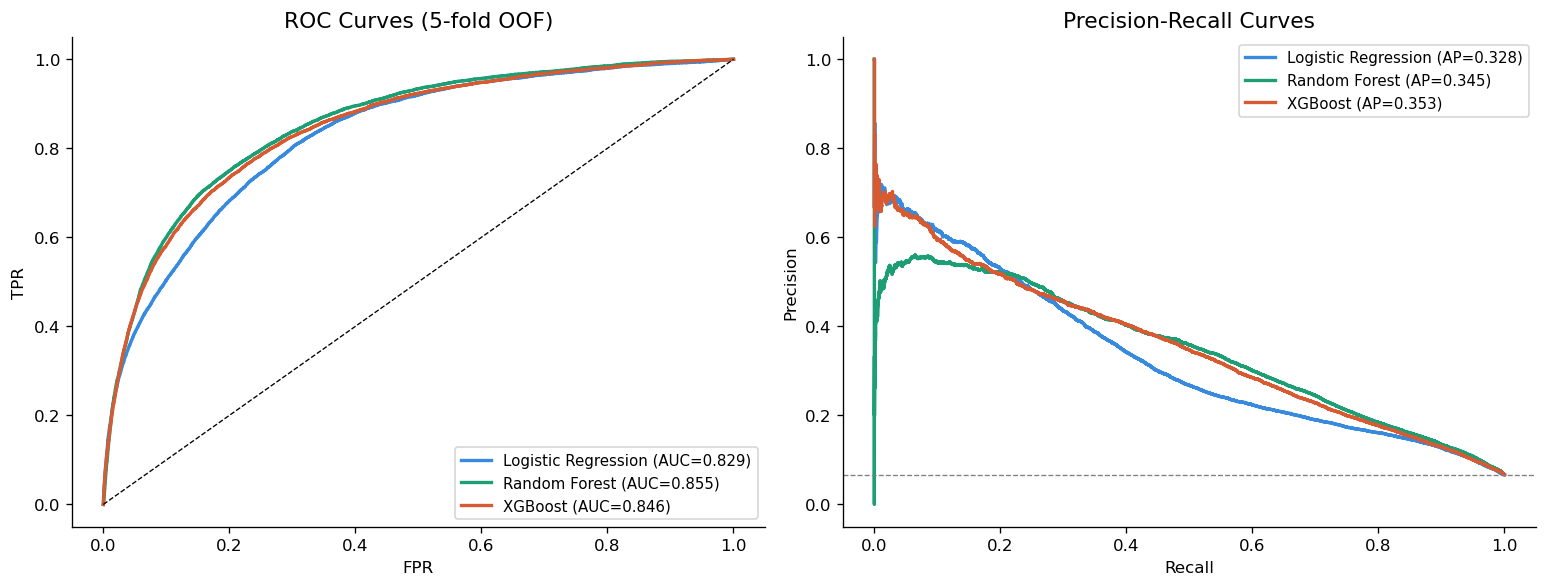

In [11]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
mc = {'Logistic Regression':PAL['lr'],'Random Forest':PAL['rf'],'XGBoost':PAL['xgb']}
for name, probs in oof_probs.items():
    c = mc[name]
    fpr,tpr,_ = roc_curve(y, probs)
    axes[0].plot(fpr, tpr, color=c, lw=2, label=f'{name} (AUC={roc_auc_score(y,probs):.3f})')
    prec,rec,_ = precision_recall_curve(y, probs)
    axes[1].plot(rec, prec, color=c, lw=2, label=f'{name} (AP={average_precision_score(y,probs):.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves (5-fold OOF)'); axes[0].legend(fontsize=9)
axes[1].axhline(y.mean(), color='gray', ls='--', lw=0.8)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('reports/roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 4. KS Plot & Confusion Matrix

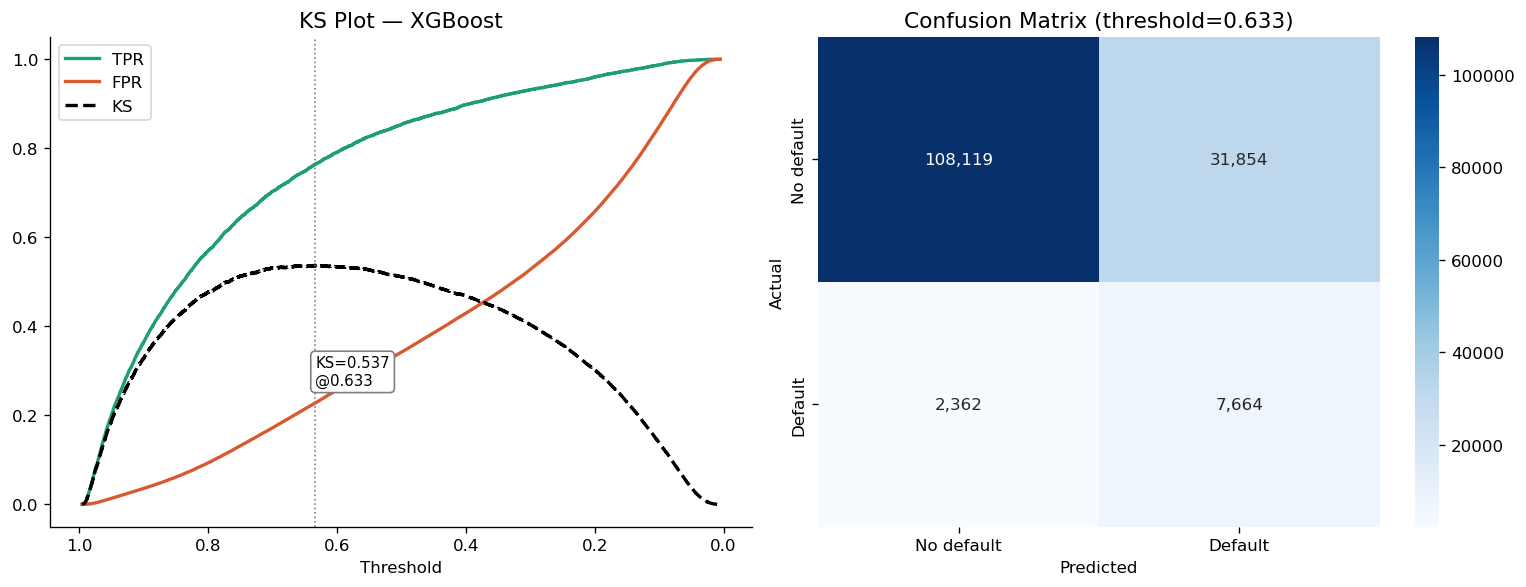

              precision    recall  f1-score   support

  No default       0.98      0.77      0.86    139973
     Default       0.19      0.76      0.31     10026

    accuracy                           0.77    149999
   macro avg       0.59      0.77      0.59    149999
weighted avg       0.93      0.77      0.83    149999

KS Statistic: 0.5368


In [12]:
xgb_probs = oof_probs['XGBoost']
fpr,tpr,thresholds = roc_curve(y, xgb_probs)
ks_idx = np.argmax(tpr-fpr); ks_val = (tpr-fpr)[ks_idx]; ks_thresh = thresholds[ks_idx]

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].plot(thresholds, tpr, color='#1D9E75', lw=2, label='TPR')
axes[0].plot(thresholds, fpr, color='#D85A30', lw=2, label='FPR')
axes[0].plot(thresholds, tpr-fpr, color='black', lw=2, ls='--', label='KS')
axes[0].annotate(f'KS={ks_val:.3f}\n@{ks_thresh:.3f}', xy=(ks_thresh,ks_val/2), fontsize=9,
                  bbox=dict(boxstyle='round,pad=0.3',facecolor='white',edgecolor='gray'))
axes[0].axvline(ks_thresh, color='gray', ls=':', lw=1)
axes[0].set_xlabel('Threshold'); axes[0].set_title('KS Plot — XGBoost')
axes[0].legend(); axes[0].invert_xaxis()

y_pred = (xgb_probs >= ks_thresh).astype(int)
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[1],
            xticklabels=['No default','Default'], yticklabels=['No default','Default'])
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
axes[1].set_title(f'Confusion Matrix (threshold={ks_thresh:.3f})')
plt.tight_layout()
plt.savefig('reports/ks_confusion.png', bbox_inches='tight')
plt.show()
print(classification_report(y, y_pred, target_names=['No default','Default']))
print(f'KS Statistic: {ks_val:.4f}')

## 5. Fit Final Models & Save

In [13]:
print('Fitting final models on full data...')

scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)
lr_final = LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced', random_state=SEED)
lr_final.fit(X_scaled, y)
joblib.dump(lr_final,     'models/lr_final.pkl')
joblib.dump(scaler_final, 'models/scaler.pkl')
print('Logistic Regression saved ✓')

xgb_final = xgb.XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
    eval_metric='auc', use_label_encoder=False, random_state=SEED, n_jobs=-1)
xgb_final.fit(X, y)
xgb_final.save_model('models/xgb_final.json')
print('XGBoost saved ✓')

PDO=20; BASE_SCORE=600; BASE_ODDS=50
Factor=PDO/np.log(2); Offset=BASE_SCORE-Factor*np.log(BASE_ODDS)
joblib.dump({'Factor':Factor,'Offset':Offset,'PDO':PDO,'BASE_SCORE':BASE_SCORE,'BASE_ODDS':BASE_ODDS},
            'models/scorecard_params.pkl')

oof_df = pd.DataFrame({'y_true':y.values, 'lr_prob':oof_probs['Logistic Regression'],
                        'rf_prob':oof_probs['Random Forest'], 'xgb_prob':oof_probs['XGBoost']})
oof_df.to_parquet('data/oof_probs.parquet', index=False)
results_df.to_csv('reports/model_comparison.csv')

print('All outputs saved ')

Fitting final models on full data...
Logistic Regression saved ✓
XGBoost saved ✓
All outputs saved 
